In [ ]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import rasterio
from rasterio.fill import fillnodata
from rasterio.windows import from_bounds, Window
from rasterio.transform import rowcol
from rasterio.plot import show

import xarray as xr
from pysheds.grid import Grid

import matplotlib.pyplot as plt
from matplotlib import colors
import seaborn as sns

In [3]:
root = Path(os.getcwd())
data_root = root / "data"

### Calculate watershed size (pyshed)

In [173]:
dtm_dir = data_root / "DTM_rlp"
dtm_path = dtm_dir / "DTM Germany_Rheinland-Pfalz 20m.tif"
dtm_crop_path = dtm_dir / "dtm_crop.tif"

print(dtm_path)
print(dtm_crop_path)

c:\Users\Administrator\PythonProjects\abfluss_queich\data\DTM_rlp\DTM Germany_Rheinland-Pfalz 20m.tif
c:\Users\Administrator\PythonProjects\abfluss_queich\data\DTM_rlp\dtm_crop.tif


In [ ]:
minx, miny, maxx, maxy = 400264, 5436526, 440273, 5465599

with rasterio.open(dtm_path) as src:
    window = from_bounds(minx, miny, maxx, maxy, src.transform)
    
    cropped = src.read(1, window=window)
    transform = src.window_transform(window)
    
    profile = src.profile.copy()
    profile.update({
        "height": cropped.shape[0],
        "width": cropped.shape[1],
        "transform": transform
    })

output_path = dtm_dir / "dtm_crop_bbo_test.tif"

with rasterio.open(output_path, "w", **profile) as dst:
    dst.write(cropped, 1)

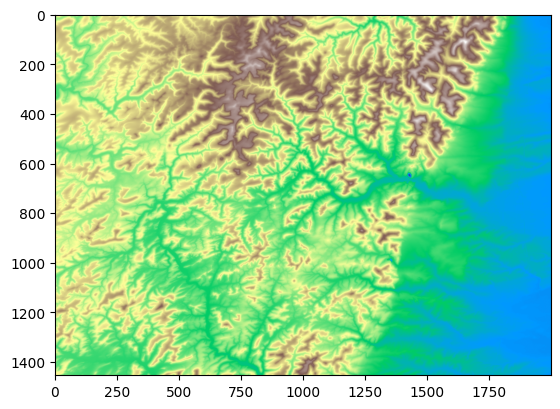

In [193]:
plt.imshow(cropped, cmap="terrain")

In [223]:
# Read tif as pysed raster
grid = Grid.from_raster(str(dtm_crop_path))
dem = grid.read_raster(str(dtm_crop_path))

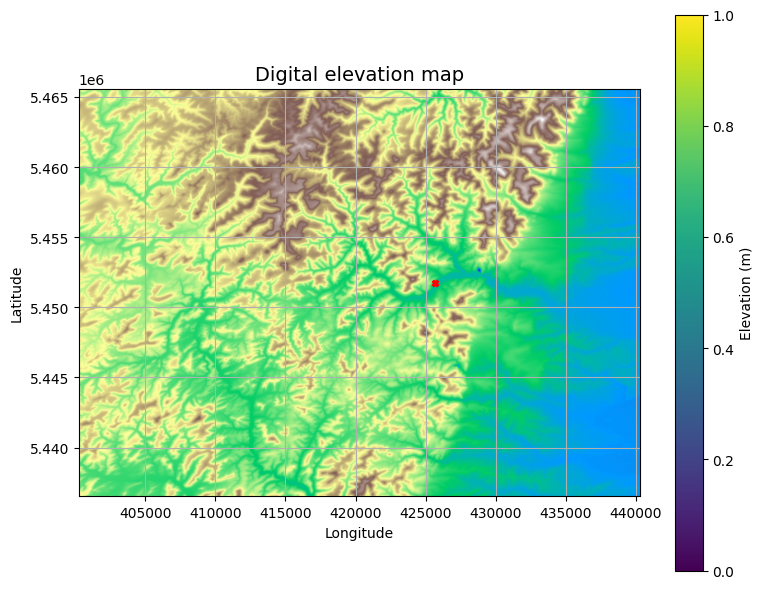

In [ ]:
x, y = 425650, 5451710 # Annweiler am Trifels
row, col = rowcol(grid.affine, x, y)

# Check DTM
fig, ax = plt.subplots(figsize=(8,6))
fig.patch.set_alpha(0)

plt.imshow(dem, extent=grid.extent, cmap='terrain', zorder=1)
plt.scatter(x, y, c="red", s=20, marker="X")
plt.colorbar(label='Elevation (m)')
plt.grid(zorder=0)
plt.title('Digital elevation map', size=14)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()

In [153]:
# --- Condition DEM ---

# Fill pits in DEM
pit_filled_dem = grid.fill_pits(dem)

# Fill depressions in DEM
flooded_dem = grid.fill_depressions(pit_filled_dem)
    
# Resolve flats in DEM
inflated_dem = grid.resolve_flats(flooded_dem)

In [232]:
# Determine D8 flow directions from DEM
# ----------------------
# Specify directional mapping
dirmap = (64, 128, 1, 2, 4, 8, 16, 32)
    
# Compute flow directions
# -------------------------------------
fdir = grid.flowdir(inflated_dem, dirmap=dirmap)

# Calculate flow accumulation
# --------------------------
acc = grid.accumulation(fdir, dirmap=dirmap)

In [ ]:
# Delineate a catchment
# ---------------------
# Specify pour point
# x, y = 425650, 5451710 # Annweiler am Trifels
x, y =  430911, 5451088 # Siebeldingen

# Snap pour point to high accumulation cell
x_snap, y_snap = grid.snap_to_mask(acc > 1000, (x, y))

# Delineate the catchment
catch = grid.catchment(x=x_snap, y=y_snap, fdir=fdir, dirmap=dirmap, 
                       xytype='coordinate')

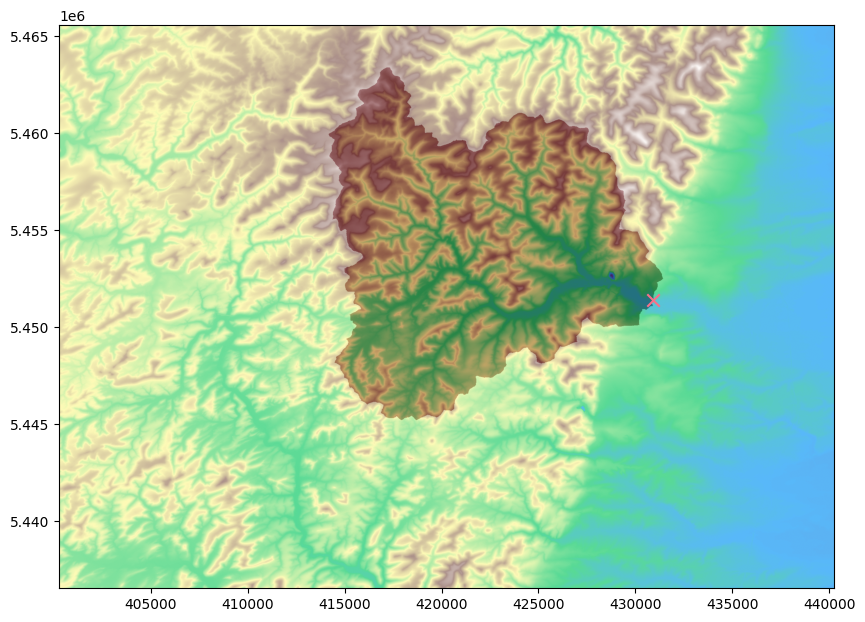

In [ ]:
# x, y = 425650, 5451710 # Annweiler am Trifels
x, y =  430911, 5451388 # Siebeldingen

fig, ax = plt.subplots(figsize=(10,8))

show(dem, extent=grid.extent, ax=ax, cmap="terrain")
show(catch, extent=grid.extent, ax=ax, cmap="Reds", alpha=0.35)

ax.scatter(x, y, s=80, marker="x")

plt.show()

Text(0.5, 1.0, 'Delineated Catchment')

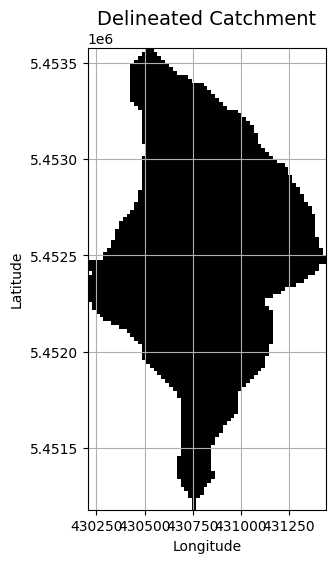

In [164]:
# Plot the catchment
fig, ax = plt.subplots(figsize=(8,6))
fig.patch.set_alpha(0)

plt.grid('on', zorder=0)
im = ax.imshow(np.where(clipped_catch, clipped_catch, np.nan), extent=grid.extent,
               zorder=1, cmap='Greys_r')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Delineated Catchment', size=14)

In [ ]:
# Combine with land cover data
# ---------------------
terrain = grid.read_raster(dtm_path, window=grid.bbox,
                           window_crs=grid.crs, nodata=0)
# Reproject data to grid's coordinate reference system
projected_terrain = terrain.to_crs(grid.crs)

# View data in catchment's spatial extent
catchment_terrain = grid.view(projected_terrain, nodata=False)

In [166]:
# Extract river network
# ---------------------
branches = grid.extract_river_network(fdir, acc > 50, dirmap=dirmap)

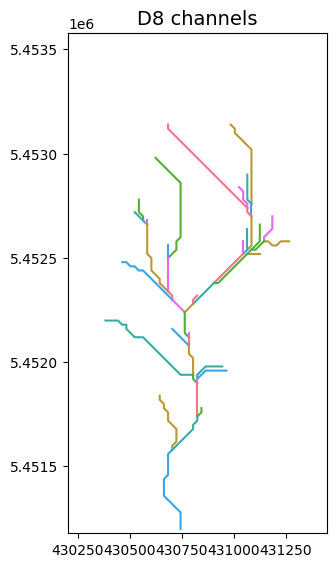

In [167]:
sns.set_palette('husl')
fig, ax = plt.subplots(figsize=(8.5,6.5))

plt.xlim(grid.bbox[0], grid.bbox[2])
plt.ylim(grid.bbox[1], grid.bbox[3])
ax.set_aspect('equal')

for branch in branches['features']:
    line = np.asarray(branch['geometry']['coordinates'])
    plt.plot(line[:, 0], line[:, 1])
    
_ = plt.title('D8 channels', size=14)

### Open hyras precip files and crop ROI

In [ ]:
hyras_dir = data_root / "precip_hyras"
hyras_paths = [p for p in hyras_dir.rglob("*.nc")]

In [7]:
ds = xr.open_dataset(hyras_paths[0])

In [24]:
ds.coords

Coordinates:
  * time     (time) datetime64[ns] 3kB 1930-01-01T06:00:00 ... 1930-12-31T06:...
    lon      (y, x) float64 5MB ...
    lat      (y, x) float64 5MB ...
  * x        (x) float64 5kB 4.022e+06 4.022e+06 ... 4.684e+06 4.686e+06
  * y        (y) float64 7kB 2.674e+06 2.676e+06 ... 3.562e+06 3.564e+06

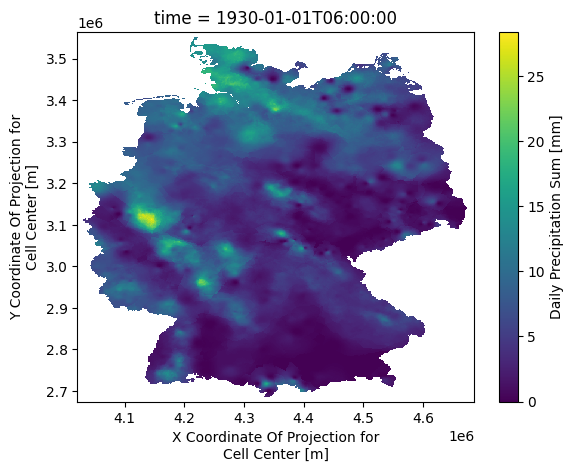

In [21]:
ds.pr.isel(time=0).plot()